In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
path = "/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET"

In [ ]:
files = os.listdir("/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion")
print(files)

['utils.py', 'Readme file - Description of Experimental Tests.txt', 'Technical Information and Experimental Test Results for LG 18650HG2.pdf', '10degC', '0degC', '25degC', '40degC', 'n10degC', 'n20degC']


In [ ]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("SMALL ANN / MLP MODEL")

SMALL ANN / MLP MODEL


In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/BATTERY_SOC_PROJECT"
DAY17_PATH = os.path.join(PROJECT_PATH, "day17_outputs")
os.makedirs(DAY17_PATH, exist_ok=True)
print("Day 17 output folder:")
print(DAY17_PATH)


Day 17 output folder:
/content/drive/MyDrive/BATTERY_SOC_PROJECT/day17_outputs


In [ ]:
def find_file(filename):
    for root, dirs, files in os.walk(PROJECT_PATH):
        if filename in files:
            return os.path.join(root, filename)
    raise FileNotFoundError(
        f"Could not find {filename} inside {PROJECT_PATH}"
    )
file_paths = {
    "feature_list": find_file("final_feature_list_day13.json"),
    "soc_train": find_file("SOC_train_engineered_day13.csv"),
    "soc_val": find_file("SOC_validation_engineered_day13.csv"),
    "soc_test": find_file("SOC_test_engineered_day13.csv"),
    "time_train": find_file("remaining_time_train_engineered_day13.csv"),
    "time_val": find_file("remaining_time_validation_engineered_day13.csv"),
    "time_test": find_file("remaining_time_test_engineered_day13.csv")
}

print("\nRequired Day 13 files found successfully.")


Required Day 13 files found successfully.


In [ ]:
with open(file_paths["feature_list"], "r") as f:
    feature_data = json.load(f)
FEATURES = None
if isinstance(feature_data, list):
    FEATURES = feature_data
elif isinstance(feature_data, dict):
    possible_keys = ["features","final_features","selected_features","feature_list","Final Features","Selected Features"]
    for key in possible_keys:
        if key in feature_data and isinstance(feature_data[key], list):
            FEATURES = feature_data[key]
            break
    if FEATURES is None:
        for value in feature_data.values():
            if isinstance(value, list) and all(
                isinstance(x, str) for x in value
            ):
                FEATURES = value
                break
if FEATURES is None:
    raise ValueError("Could not read the Day 13 feature list.")
FEATURES = list(dict.fromkeys(FEATURES))
print("\nDay 13 frozen feature list:")
print(FEATURES)
print("\nNumber of features:", len(FEATURES))


Day 13 frozen feature list:
['Voltage', 'Current', 'Temperature', 'Elapsed Time', 'Cycle', 'WhAccu', 'Power']

Number of features: 7


In [ ]:
soc_train = pd.read_csv(file_paths["soc_train"])
soc_val = pd.read_csv(file_paths["soc_val"])
soc_test = pd.read_csv(file_paths["soc_test"])
time_train = pd.read_csv(file_paths["time_train"])
time_val = pd.read_csv(file_paths["time_val"])
time_test = pd.read_csv(file_paths["time_test"])
SOC_TARGET = "SOC"
TIME_TARGET = "Remaining Charging Time"
missing_soc = [f for f in FEATURES if f not in soc_train.columns]
missing_time = [f for f in FEATURES if f not in time_train.columns]
if missing_soc:
    raise ValueError(f"Missing SOC features: {missing_soc}")
if missing_time:
    raise ValueError(f"Missing Remaining Time features: {missing_time}")
X_soc_train = soc_train[FEATURES].copy()
X_soc_val = soc_val[FEATURES].copy()
X_soc_test = soc_test[FEATURES].copy()
y_soc_train = soc_train[SOC_TARGET].copy()
y_soc_val = soc_val[SOC_TARGET].copy()
y_soc_test = soc_test[SOC_TARGET].copy()
X_time_train = time_train[FEATURES].copy()
X_time_val = time_val[FEATURES].copy()
X_time_test = time_test[FEATURES].copy()
y_time_train = time_train[TIME_TARGET].copy()
y_time_val = time_val[TIME_TARGET].copy()
y_time_test = time_test[TIME_TARGET].copy()
print("\nData loaded using the SAME Day 13 frozen split.")
print("SOC:", X_soc_train.shape, X_soc_val.shape, X_soc_test.shape)
print("Remaining Time:", X_time_train.shape, X_time_val.shape, X_time_test.shape)


Data loaded using the SAME Day 13 frozen split.
SOC: (9926, 7) (7376, 7) (2250, 7)
Remaining Time: (41015, 7) (1349, 7) (2286, 7)


In [ ]:
def prepare_numeric(X_train, X_val, X_test):
    X_train = X_train.apply(pd.to_numeric, errors="coerce")
    X_val = X_val.apply(pd.to_numeric, errors="coerce")
    X_test = X_test.apply(pd.to_numeric, errors="coerce")
    train_medians = X_train.median()
    X_train = X_train.fillna(train_medians)
    X_val = X_val.fillna(train_medians)
    X_test = X_test.fillna(train_medians)
    return X_train, X_val, X_test
X_soc_train, X_soc_val, X_soc_test = prepare_numeric(X_soc_train, X_soc_val, X_soc_test)
X_time_train, X_time_val, X_time_test = prepare_numeric(X_time_train, X_time_val, X_time_test)
print("\nBlock 5 completed: Numeric preparation done.")


Block 5 completed: Numeric preparation done.


In [ ]:
soc_x_scaler = StandardScaler()
time_x_scaler = StandardScaler()
X_soc_train_scaled = soc_x_scaler.fit_transform(X_soc_train)
X_soc_val_scaled = soc_x_scaler.transform(X_soc_val)
X_soc_test_scaled = soc_x_scaler.transform(X_soc_test)
X_time_train_scaled = time_x_scaler.fit_transform(X_time_train)
X_time_val_scaled = time_x_scaler.transform(X_time_val)
X_time_test_scaled = time_x_scaler.transform(X_time_test)

In [ ]:
soc_y_scaler = StandardScaler()
time_y_scaler = StandardScaler()
y_soc_train_scaled = soc_y_scaler.fit_transform(np.asarray(y_soc_train).reshape(-1, 1)).ravel()
y_time_train_scaled = time_y_scaler.fit_transform(np.asarray(y_time_train).reshape(-1, 1)).ravel()
print("Training scaling applied.")

Training scaling applied.


In [ ]:
print("TRAINING SMALL ANN / MLP FOR SOC")
mlp_soc = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=10,
    random_state=42
)
mlp_soc.fit(
    X_soc_train_scaled,
    y_soc_train_scaled
)
print("SOC MLP training completed.")
print("Iterations:", mlp_soc.n_iter_)

TRAINING SMALL ANN / MLP FOR SOC
SOC MLP training completed.
Iterations: 97


In [ ]:
print("TRAINING SMALL ANN / MLP FOR REMAINING CHARGING TIME")
mlp_time = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=10,
    random_state=42
)
mlp_time.fit(
    X_time_train_scaled,
    y_time_train_scaled
)
print("Remaining Time MLP training completed.")
print("Iterations:", mlp_time.n_iter_)

TRAINING SMALL ANN / MLP FOR REMAINING CHARGING TIME
Remaining Time MLP training completed.
Iterations: 26


In [ ]:
soc_train_pred_scaled = mlp_soc.predict(X_soc_train_scaled)
soc_val_pred_scaled = mlp_soc.predict(X_soc_val_scaled)
soc_test_pred_scaled = mlp_soc.predict(X_soc_test_scaled)
soc_train_pred = soc_y_scaler.inverse_transform(soc_train_pred_scaled.reshape(-1, 1)).ravel()
soc_val_pred = soc_y_scaler.inverse_transform(soc_val_pred_scaled.reshape(-1, 1)).ravel()
soc_test_pred = soc_y_scaler.inverse_transform(soc_test_pred_scaled.reshape(-1, 1)).ravel()
time_train_pred_scaled = mlp_time.predict(X_time_train_scaled)
time_val_pred_scaled = mlp_time.predict(X_time_val_scaled)
time_test_pred_scaled = mlp_time.predict(X_time_test_scaled)
time_train_pred = time_y_scaler.inverse_transform(time_train_pred_scaled.reshape(-1, 1)).ravel()
time_val_pred = time_y_scaler.inverse_transform(time_val_pred_scaled.reshape(-1, 1)).ravel()
time_test_pred = time_y_scaler.inverse_transform(time_test_pred_scaled.reshape(-1, 1)).ravel()
print("\nPredictions generated.")


Predictions generated.


In [ ]:
def calculate_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

In [ ]:
mlp_results = []
for target, dataset, y_true, y_pred in [(SOC_TARGET, "Train", y_soc_train, soc_train_pred),(SOC_TARGET, "Validation", y_soc_val, soc_val_pred),(SOC_TARGET, "Test", y_soc_test, soc_test_pred),(TIME_TARGET, "Train", y_time_train, time_train_pred),(TIME_TARGET, "Validation", y_time_val, time_val_pred),(TIME_TARGET, "Test", y_time_test, time_test_pred)]:
    metrics = calculate_metrics(y_true, y_pred)
    mlp_results.append({
        "Target": target,
        "Model": "Small ANN / MLP",
        "Dataset": dataset,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R2": metrics["R2"]
    })
mlp_results_df = pd.DataFrame(mlp_results)
print("MLP RESULTS")
display(mlp_results_df)

MLP RESULTS


,Target,Model,Dataset,MAE,RMSE,R2
0,SOC,Small ANN / MLP,Train,0.830483,2.342074,0.996898
1,SOC,Small ANN / MLP,Validation,11.614762,17.777087,0.512942
2,SOC,Small ANN / MLP,Test,2.628960,3.993360,0.990619
3,Remaining Charging Time,Small ANN / MLP,Train,93.744847,174.943598,0.999824
4,Remaining Charging Time,Small ANN / MLP,Validation,85.539953,117.117022,0.993412
5,Remaining Charging Time,Small ANN / MLP,Test,713.387572,1003.307039,0.998042


In [ ]:
mlp_results_path = os.path.join(DAY17_PATH,"day17_mlp_results.csv")
mlp_results_df.to_csv(
    mlp_results_path,
    index=False)

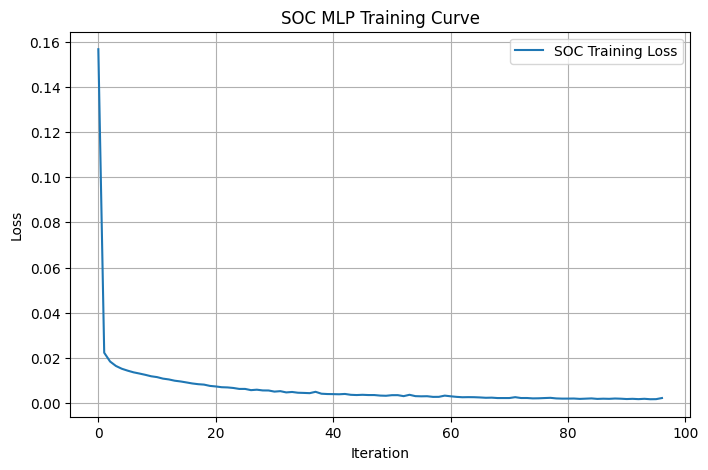

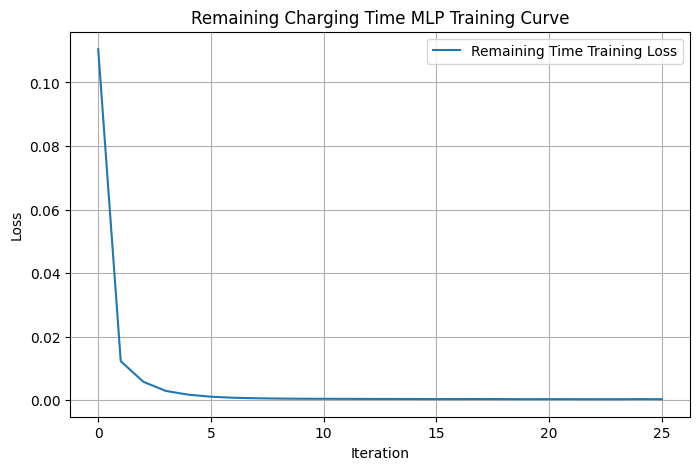

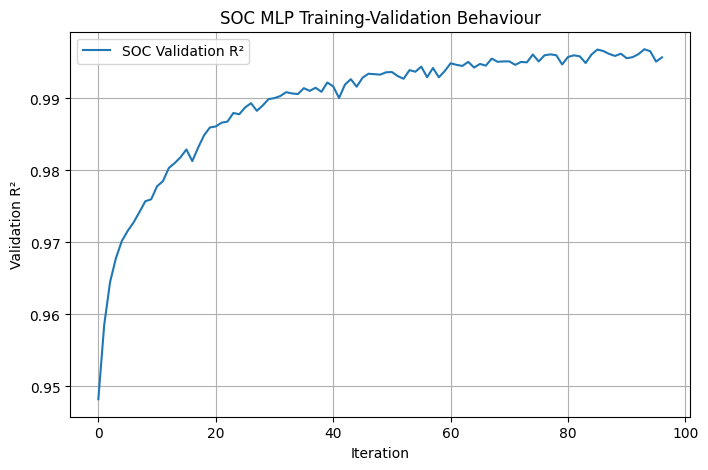

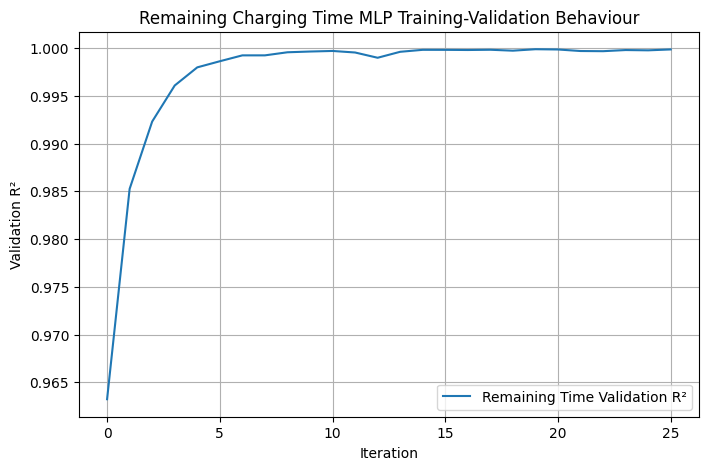

 Training and validation curves saved.


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(
    mlp_soc.loss_curve_,label="SOC Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("SOC MLP Training Curve")
plt.legend()
plt.grid(True)
soc_curve_path = os.path.join(DAY17_PATH,"SOC_MLP_training_curve.png")
plt.savefig(soc_curve_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    mlp_time.loss_curve_,label="Remaining Time Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Remaining Charging Time MLP Training Curve")
plt.legend()
plt.grid(True)
time_curve_path = os.path.join(DAY17_PATH,"Remaining_Time_MLP_training_curve.png")
plt.savefig(time_curve_path, dpi=300, bbox_inches="tight")
plt.show()
if hasattr(mlp_soc, "validation_scores_"):
    plt.figure(figsize=(8, 5))
    plt.plot(
        mlp_soc.validation_scores_,label="SOC Validation R²")
    plt.xlabel("Iteration")
    plt.ylabel("Validation R²")
    plt.title("SOC MLP Training-Validation Behaviour")
    plt.legend()
    plt.grid(True)
    path = os.path.join(DAY17_PATH,"SOC_MLP_validation_curve.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
if hasattr(mlp_time, "validation_scores_"):
    plt.figure(figsize=(8, 5))
    plt.plot(
        mlp_time.validation_scores_,label="Remaining Time Validation R²")
    plt.xlabel("Iteration")
    plt.ylabel("Validation R²")
    plt.title("Remaining Charging Time MLP Training-Validation Behaviour")
    plt.legend()
    plt.grid(True)
    path = os.path.join(DAY17_PATH,"Remaining_Time_MLP_validation_curve.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
print(" Training and validation curves saved.")




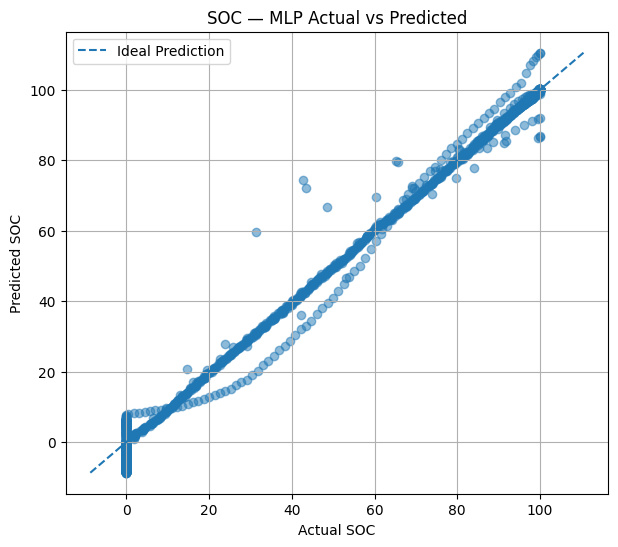

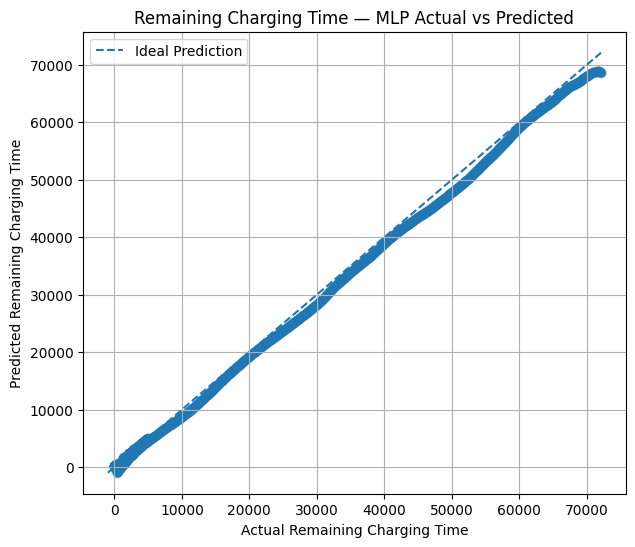

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(y_soc_test,soc_test_pred,alpha=0.5)
min_val = min(np.min(y_soc_test), np.min(soc_test_pred))
max_val = max(np.max(y_soc_test), np.max(soc_test_pred))
plt.plot([min_val, max_val],[min_val, max_val],linestyle="--",label="Ideal Prediction")
plt.xlabel("Actual SOC")
plt.ylabel("Predicted SOC")
plt.title("SOC — MLP Actual vs Predicted")
plt.legend()
plt.grid(True)
soc_pred_plot = os.path.join(DAY17_PATH,"SOC_MLP_actual_vs_predicted.png")
plt.savefig(soc_pred_plot, dpi=300, bbox_inches="tight")
plt.show()
plt.figure(figsize=(7, 6))
plt.scatter(y_time_test,time_test_pred,alpha=0.5)
min_val = min(np.min(y_time_test), np.min(time_test_pred))
max_val = max(np.max(y_time_test), np.max(time_test_pred))
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Ideal Prediction"
)
plt.xlabel("Actual Remaining Charging Time")
plt.ylabel("Predicted Remaining Charging Time")
plt.title("Remaining Charging Time — MLP Actual vs Predicted")
plt.legend()
plt.grid(True)
time_pred_plot = os.path.join(DAY17_PATH,"Remaining_Time_MLP_actual_vs_predicted.png")
plt.savefig(time_pred_plot, dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
soc_prediction_table = pd.DataFrame({"Actual_SOC": np.asarray(y_soc_test),"Predicted_SOC_MLP": soc_test_pred})
time_prediction_table = pd.DataFrame({"Actual_Remaining_Charging_Time": np.asarray(y_time_test),"Predicted_Remaining_Charging_Time_MLP": time_test_pred})
soc_prediction_path = os.path.join(DAY17_PATH,"SOC_MLP_test_predictions.csv")
time_prediction_path = os.path.join(DAY17_PATH,"Remaining_Time_MLP_test_predictions.csv")
soc_prediction_table.to_csv(
    soc_prediction_path,
    index=False
)
time_prediction_table.to_csv(
    time_prediction_path,
    index=False
)
print("\nSOC MLP test predictions:")
display(soc_prediction_table.head(20))
print("\nRemaining Charging Time MLP test predictions:")
display(time_prediction_table.head(20))


SOC MLP test predictions:


,Actual_SOC,Predicted_SOC_MLP
0,2.108060,2.154211
1,4.215699,3.864830
2,6.324181,5.523916
3,8.431819,7.442492
4,10.539458,9.625972
5,12.647518,11.826386
6,14.755156,14.028390
7,16.863217,16.108886
8,18.971277,18.190033
9,21.079337,20.712432



Remaining Charging Time MLP test predictions:


,Actual_Remaining_Charging_Time,Predicted_Remaining_Charging_Time_MLP
0,245.0,468.681311
1,185.0,378.082050
2,125.0,285.904719
3,65.0,250.168968
4,5.0,220.707948
5,0.0,214.996001
6,4790.0,4508.986083
7,4730.0,4638.890720
8,4670.0,4683.108777
9,4610.0,4576.450178


In [ ]:
comparison_tables = []

comparison_tables.append(
    mlp_results_df[mlp_results_df["Dataset"] == "Test"].copy())
try:
    day15_file = find_file("day15_baseline_results.csv")
    day15_df = pd.read_csv(day15_file)
    comparison_tables.append(
        day15_df[day15_df["Dataset"] == "Test"].copy())
    print("\nDay 15 baseline loaded for comparison.")
except Exception as e:
    print("\nDay 15 baseline could not be loaded:", e)
try:
    day16_file = find_file("day16_tuned_model_results.csv")
    day16_df = pd.read_csv(day16_file)
    comparison_tables.append(
        day16_df[day16_df["Dataset"] == "Test"].copy())
    print("Day 16 tuned models loaded for comparison.")
except Exception as e:
    print("\nDay 16 tuned results could not be loaded:", e)
comparison_df = pd.concat(
    comparison_tables,
    ignore_index=True)
comparison_df = comparison_df[
    ["Target", "Model", "Dataset", "MAE", "RMSE", "R2"]]
print("DAY 17 MODEL COMPARISON — TEST SET")
display(comparison_df)
comparison_path = os.path.join(
    DAY17_PATH,"day17_model_comparison_with_previous_models.csv")
comparison_df.to_csv(
    comparison_path,
    index=False)


Day 15 baseline loaded for comparison.
Day 16 tuned models loaded for comparison.
DAY 17 MODEL COMPARISON — TEST SET


,Target,Model,Dataset,MAE,RMSE,R2
0,SOC,Small ANN / MLP,Test,2.628960,3.993360,0.990619
1,Remaining Charging Time,Small ANN / MLP,Test,713.387572,1003.307039,0.998042
2,SOC,NaN,Test,4.681095,11.754876,0.918719
3,Remaining Charging Time,NaN,Test,8817.875379,12224.276890,0.709272
4,SOC,Random Forest Tuned,Test,0.753528,4.014321,0.990521
5,Remaining Charging Time,Random Forest Tuned,Test,542.106640,799.685272,0.998756
6,SOC,XGBoost Tuned,Test,1.047517,3.691105,0.991986
7,Remaining Charging Time,XGBoost Tuned,Test,969.298032,1512.148424,0.995551


In [ ]:
complexity_note = """
DAY 17 MODEL JUSTIFICATION AND INITIAL FINDINGS

A small Multi-Layer Perceptron (MLP) was added as an additional
non-linear model for comparison with the simpler Linear Regression
baseline and tree-based Random Forest / XGBoost models.
The MLP uses two small hidden layers (64 and 32 neurons) with ReLU
activation. Standardization is fitted only on the training data.
Early stopping and an internal validation fraction are used to
monitor training behaviour and reduce unnecessary training.
The MLP is treated as an additional comparison model rather than
automatically being selected as the final model.
Final model direction will be based on validation/test MAE, RMSE,
R2, generalization behaviour and model complexity.
"""
note_path = os.path.join(DAY17_PATH,"day17_initial_findings.txt")
with open(note_path, "w") as f:
    f.write(complexity_note)

In [ ]:
soc_mlp_artifact = {
    "model": mlp_soc,
    "X_scaler": soc_x_scaler,
    "y_scaler": soc_y_scaler,
    "features": FEATURES,
    "target": SOC_TARGET
}
time_mlp_artifact = {
    "model": mlp_time,
    "X_scaler": time_x_scaler,
    "y_scaler": time_y_scaler,
    "features": FEATURES,
    "target": TIME_TARGET
}
soc_model_path = os.path.join(DAY17_PATH,"SOC_MLP_model_artifact_day17.joblib")
time_model_path = os.path.join(DAY17_PATH,"Remaining_Time_MLP_model_artifact_day17.joblib")
joblib.dump(
    soc_mlp_artifact,
    soc_model_path
)
joblib.dump(
    time_mlp_artifact,
    time_model_path
)

['/content/drive/MyDrive/BATTERY_SOC_PROJECT/day17_outputs/Remaining_Time_MLP_model_artifact_day17.joblib']

In [ ]:
model_parameters = {
    "model": "Small ANN / MLP",
    "hidden_layers": [64, 32],
    "activation": "relu",
    "solver": "adam",
    "alpha": 0.001,
    "learning_rate_init": 0.001,
    "max_iter": 100,
    "early_stopping": True,
    "validation_fraction": 0.15,
    "n_iter_no_change": 10,
    "random_state": 42,
    "features": FEATURES,
    "targets": [
        SOC_TARGET,
        TIME_TARGET
    ]
}
parameters_path = os.path.join(DAY17_PATH,"day17_mlp_parameters.json")
with open(parameters_path, "w") as f:
    json.dump(
        model_parameters,
        f,
        indent=4
    )

In [ ]:
print("DAY 17 COMPLETED SUCCESSFULLY")
print("\nSaved outputs:")
print("1.", mlp_results_path)
print("2.", comparison_path)
print("3.", soc_curve_path)
print("4.", time_curve_path)
print("5.", soc_prediction_path)
print("6.", time_prediction_path)
print("7.", soc_model_path)
print("8.", time_model_path)
print("9.", parameters_path)
print("10.", note_path)
print("\n Day 17 MLP notebook, metrics, curves,")
print("comparisons and model artifacts saved successfully.")

DAY 17 COMPLETED SUCCESSFULLY

Saved outputs:
1. /content/drive/MyDrive/BATTERY_SOC_PROJECT/day17_outputs/day17_mlp_results.csv
2. /content/drive/MyDrive/BATTERY_SOC_PROJECT/day17_outputs/day17_model_comparison_with_previous_models.csv
3. /content/drive/MyDrive/BATTERY_SOC_PROJECT/day17_outputs/SOC_MLP_training_curve.png
4. /content/drive/MyDrive/BATTERY_SOC_PROJECT/day17_outputs/Remaining_Time_MLP_training_curve.png
5. /content/drive/MyDrive/BATTERY_SOC_PROJECT/day17_outputs/SOC_MLP_test_predictions.csv
6. /content/drive/MyDrive/BATTERY_SOC_PROJECT/day17_outputs/Remaining_Time_MLP_test_predictions.csv
7. /content/drive/MyDrive/BATTERY_SOC_PROJECT/day17_outputs/SOC_MLP_model_artifact_day17.joblib
8. /content/drive/MyDrive/BATTERY_SOC_PROJECT/day17_outputs/Remaining_Time_MLP_model_artifact_day17.joblib
9. /content/drive/MyDrive/BATTERY_SOC_PROJECT/day17_outputs/day17_mlp_parameters.json
10. /content/drive/MyDrive/BATTERY_SOC_PROJECT/day17_outputs/day17_initial_findings.txt

 Day 17 MLP 